In [1]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
MODEL_PATH = "Modelos/best_dog_emotion_model_final_2.keras"  # Cambia esto por tu archivo real

model = tf.keras.models.load_model(MODEL_PATH)

print("Modelo cargado correctamente")
model.summary()

Modelo cargado correctamente


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,642,010 (25.34 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 361,350 (1.38 MB)

In [5]:
IMG_SIZE = (224, 224)  # Usa el mismo tamaño que usaste al entrenar

CLASS_NAMES = ["angry", "happy", "relaxed", "sad"]  # Cambia según tus clases

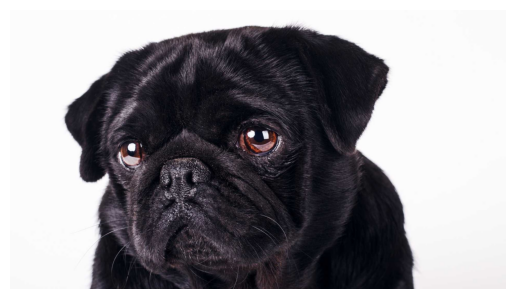

Shape de entrada: (1, 224, 224, 3)


In [6]:
IMAGE_PATH = "Test_data/perro_triste.jpg"  # Cambia esto por tu imagen

img = Image.open(IMAGE_PATH).convert("RGB")
img_resized = img.resize(IMG_SIZE)

img_array = np.array(img_resized)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.axis("off")
plt.show()

print("Shape de entrada:", img_array.shape)

In [7]:
predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])
predicted_class = CLASS_NAMES[predicted_index]
confidence = predictions[0][predicted_index]

print("Clase predicha:", predicted_class)
print(f"Confianza: {confidence:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Clase predicha: sad
Confianza: 34.08%


In [8]:
for class_name, prob in zip(CLASS_NAMES, predictions[0]):
    print(f"{class_name}: {prob:.2%}")

angry: 22.05%
happy: 20.35%
relaxed: 23.52%
sad: 34.08%
